# Aggregated MALS Result Plots

Reads `result/plot/aggregated-direct` and `result/plot/aggregated-materialized` using the shared structures from `scripts/common.py`, then plots the main metrics with matplotlib.

Metrics shown: `identifier_f1`, `edit_similarity`, and `hallucination_rate`.


In [418]:
from __future__ import annotations

from dataclasses import dataclass, replace
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'result').exists() and (candidate / 'scripts' / 'common.py').exists():
            return candidate
    raise RuntimeError('Could not find repo root')

ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.common import (
    read_direct_aggregation_result,
    read_materialized_aggregation_result,
)

PLOT_ROOT = ROOT / '..' / 'mals-test-results' / 'plot'
DIRECT_ROOT = PLOT_ROOT / 'aggregated-direct'
MATERIALIZED_ROOT = PLOT_ROOT / 'aggregated-materialized'

SERVER_LABELS = {'mals-adapter': 'mals'}
SERVER_COLORS = {'mals': '#1f77b4', 'mals-lsp': '#ff7f0e', 'lsp-ai':  '#d62728', 'llm-ls': '#2ca02c'}


LANG = 'ru'  # 'ru' or 'en'

TEXTS = {
    'en': {
        'no_data': 'No data for {metric}',
        'identifier_f1': 'Identifier F1',
        'edit_similarity': 'Edit similarity',
        'hallucination_rate': 'Hallucination rate',
        'new_diagnostic_count': 'New diagnostics',
        'completion_diagnostic_count': 'Completion diagnostics',
        'by_dataset_language_identifier_f1': 'Identifier F1 by dataset/language',
        'by_dataset_language_edit_similarity': 'Edit similarity by dataset/language',
        'by_dataset_language_hallucination_rate': 'Hallucination rate by dataset/language',
        'by_dataset_identifier_f1': 'Identifier F1 aggregated across languages',
        'by_dataset_edit_similarity': 'Edit similarity aggregated across languages',
        'by_dataset_hallucination_rate': 'Hallucination rate aggregated across languages',
        'overall_identifier_f1': 'Overall identifier F1',
        'overall_edit_similarity': 'Overall edit similarity',
        'overall_hallucination_rate': 'Overall hallucination rate',
        'diagnostics_new': 'New diagnostics aggregated across languages',
        'diagnostics_completion': 'Completion diagnostics aggregated across languages',
    },
    'ru': {
        'no_data': 'Нет данных для {metric}',
        'identifier_f1': 'Identifier F1',
        'edit_similarity': 'Edit Similarity',
        'hallucination_rate': 'Hallucination Rate',
        'new_diagnostic_count': 'Новые диагностики',
        'completion_diagnostic_count': 'Диагностики автодополнения',
        'by_dataset_language_identifier_f1': 'Identifier F1 по датасету/языку',
        'by_dataset_language_edit_similarity': 'Edit Similarity по датасету/языку',
        'by_dataset_language_hallucination_rate': 'Hallucination Rate по датасету/языку',
        'by_dataset_identifier_f1': 'Identifier F1, агрегация по языкам',
        'by_dataset_edit_similarity': 'Edit Similarity, агрегация по языкам',
        'by_dataset_hallucination_rate': 'Hallucination Rate, агрегация по языкам',
        'overall_identifier_f1': 'Identifier F1, общий',
        'overall_edit_similarity': 'Edit Similarity, общий',
        'overall_hallucination_rate': 'Hallucination Rate, общий',
        'diagnostics_new': 'Новые диагностики, агрегация по языкам',
        'diagnostics_completion': 'Диагностики автодополнения, агрегация по языкам',
    },
}

def text(key: str, **kwargs) -> str:
    return TEXTS[LANG][key].format(**kwargs)

def metric_label(metric: str) -> str:
    return TEXTS[LANG].get(metric, metric)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


In [419]:
@dataclass(frozen=True)
class DirectMetricRow:
    dataset: str
    language: str
    server: str
    count: int
    identifier_f1: float
    edit_similarity: float
    exact_match: float

@dataclass(frozen=True)
class MaterializedDiagnosticRow:
    dataset: str
    language: str
    server: str
    count: int
    hallucination_rate: float
    new_diagnostic_count: float
    completion_diagnostic_count: float

@dataclass(frozen=True)
class MetricRow:
    dataset: str = ''
    language: str = ''
    server: str = ''
    count: int = 0
    identifier_f1: float | None = None
    edit_similarity: float | None = None
    exact_match: float | None = None
    hallucination_rate: float | None = None
    new_diagnostic_count: float | None = None
    completion_diagnostic_count: float | None = None
    label: str = ''

def server_label(value: str) -> str:
    return SERVER_LABELS.get(value, value)

def load_direct_rows(root: Path) -> list[DirectMetricRow]:
    rows = []
    for path in sorted(root.glob('*/*.json')):
        result = read_direct_aggregation_result(path)
        for item in result.summary:
            dataset = item.group.get('dataset') or path.parent.name
            language = item.group.get('language') or ''
            server = server_label(item.group.get('server') or path.stem)
            rows.append(DirectMetricRow(
                dataset=dataset,
                language=language,
                server=server,
                count=item.count,
                identifier_f1=item.best_metrics.identifier_f1,
                edit_similarity=item.best_metrics.edit_similarity,
                exact_match=item.best_metrics.exact_match,
            ))
    return rows

def load_materialized_rows(root: Path) -> list[MaterializedDiagnosticRow]:
    rows = []
    for path in sorted(root.glob('*/*.json')):
        result = read_materialized_aggregation_result(path)
        for item in result.summary:
            if item.completion_count == 0:
                continue
            dataset = item.group.get('dataset') or path.parent.name
            language = item.group.get('language') or ''
            server = server_label(item.group.get('server') or path.stem)
            rows.append(MaterializedDiagnosticRow(
                dataset=dataset,
                language=language,
                server=server,
                count=item.count,
                hallucination_rate=item.best_hallucination_rate,
                new_diagnostic_count=item.best_new_diagnostic_count,
                completion_diagnostic_count=item.best_completion_diagnostic_count,
            ))
    return rows

direct_rows = load_direct_rows(DIRECT_ROOT)
materialized_rows = load_materialized_rows(MATERIALIZED_ROOT)

print(f"direct rows: {len(direct_rows)}")
print(f"materialized rows: {len(materialized_rows)}")
print('datasets:', sorted({r.dataset for r in direct_rows + materialized_rows}))
print('servers:', sorted({r.server for r in direct_rows + materialized_rows}))


direct rows: 36
materialized rows: 36
datasets: ['cceval', 'humanevalpack', 'repobench-c']
servers: ['llm-ls', 'lsp-ai', 'mals']


In [420]:
def weighted_mean(items: list[MetricRow], metric: str) -> float | None:
    values = [(getattr(row, metric), row.count or 1) for row in items if getattr(row, metric) is not None]
    if not values:
        return None
    total = sum(weight for _, weight in values)
    return sum(value * weight for value, weight in values) / total

def aggregate(rows: list[MetricRow], group_by: list[str], metrics: list[str]) -> list[MetricRow]:
    groups = defaultdict(list)
    for row in rows:
        groups[tuple(getattr(row, field) for field in group_by)].append(row)

    result = []
    for key, items in sorted(groups.items()):
        values = {field: value for field, value in zip(group_by, key)}
        values['count'] = sum(row.count for row in items)
        values.update({metric: weighted_mean(items, metric) for metric in metrics})
        result.append(MetricRow(**values))
    return result

def join_metric_rows() -> list[MetricRow]:
    rows = {
        (r.dataset, r.language, r.server): MetricRow(
            dataset=r.dataset,
            language=r.language,
            server=r.server,
            count=r.count,
            identifier_f1=r.identifier_f1,
            edit_similarity=r.edit_similarity,
            exact_match=r.exact_match,
        )
        for r in direct_rows
    }
    for row in materialized_rows:
        key = (row.dataset, row.language, row.server)
        current = rows.get(key, MetricRow(dataset=row.dataset, language=row.language, server=row.server, count=row.count))
        rows[key] = replace(
            current,
            count=max(current.count, row.count),
            hallucination_rate=row.hallucination_rate,
            new_diagnostic_count=row.new_diagnostic_count,
            completion_diagnostic_count=row.completion_diagnostic_count,
        )
    return sorted(rows.values(), key=lambda r: (r.dataset, r.language, r.server))

metric_rows = join_metric_rows()
metric_rows[:3]


[MetricRow(dataset='cceval', language='csharp', server='llm-ls', count=12, identifier_f1=0.39087301587301587, edit_similarity=0.4193553470262888, exact_match=0.0, hallucination_rate=0.4133333333333334, new_diagnostic_count=21.666666666666668, completion_diagnostic_count=23.25, label=''),
 MetricRow(dataset='cceval', language='csharp', server='lsp-ai', count=20, identifier_f1=0.5846647193386324, edit_similarity=0.48157317869268784, exact_match=0.05, hallucination_rate=0.425, new_diagnostic_count=20.3, completion_diagnostic_count=24.75, label=''),
 MetricRow(dataset='cceval', language='csharp', server='mals', count=20, identifier_f1=0.49632167349558654, edit_similarity=0.41247684427305825, exact_match=0.0, hallucination_rate=0.5, new_diagnostic_count=23.2, completion_diagnostic_count=24.15, label='')]

In [421]:
def plot_grouped_bars(rows: list[MetricRow], metric: str, title: str, x_field: str = "label"):
    rows = [row for row in rows if getattr(row, metric) is not None]
    labels = sorted({getattr(row, x_field) for row in rows})
    servers = sorted({row.server for row in rows})
    values = {(getattr(row, x_field), row.server): getattr(row, metric) for row in rows}

    if not labels:
        print(text('no_data', metric=metric_label(metric)))
        return

    width = 0.8 / max(len(servers), 1)
    x = list(range(len(labels)))
    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.8), 5))

    for i, server in enumerate(servers):
        offset = (i - (len(servers) - 1) / 2) * width
        y = [values.get((label, server), 0) for label in labels]
        xpos = [pos + offset for pos in x]
        color = SERVER_COLORS.get(server)
        print(server, metric, y)
        ax.bar(xpos, y, width, label=server, color=color, edgecolor='black', linewidth=0.4)

    ax.set_title(title)
    ax.set_ylabel(metric_label(metric))
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    if all((getattr(row, metric) is None or 0 <= getattr(row, metric) <= 1) for row in rows):
        ax.set_ylim(0, 1)
    ax.legend()
    fig.tight_layout()
    plt.show()

def add_label(rows: list[MetricRow], *fields: str) -> list[MetricRow]:
    return [
        replace(row, label=' / '.join(str(getattr(row, field)) for field in fields if getattr(row, field)))
        for row in rows
    ]

def plot_server_bars(rows: list[MetricRow], metric: str, title: str):
    rows = [row for row in rows if getattr(row, metric) is not None]
    if not rows:
        print(text('no_data', metric=metric_label(metric)))
        return

    rows = sorted(rows, key=lambda row: row.server)
    labels = [row.server for row in rows]
    values = [getattr(row, metric) for row in rows]
    colors = [SERVER_COLORS.get(row.server) for row in rows]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.4)
    print(metric, *zip(labels, values))

    ax.set_title(title)
    ax.set_ylabel(metric_label(metric))
    if all(0 <= value <= 1 for value in values):
        ax.set_ylim(0, 1)
    fig.tight_layout()
    plt.show()


## Per Dataset / Language


llm-ls identifier_f1 [0.39087301587301587, 0.46145833333333336, 0.2572039072039072, 0.39381313042216365, 0.4997727513086089, 0.3491120971511481, 0.4803713161088437, 0.28914693445666484, 0.25433510145192256, 0.4054054054054054, 0.16266016982125947, 0.28788645911004085]
lsp-ai identifier_f1 [0.5846647193386324, 0.4692507492507492, 0.3723669467787115, 0.17788220551378445, 0.4416453556719062, 0.3757847842299041, 0.4355998761248085, 0.2752642822105438, 0.3651039746954885, 0.3085189807831628, 0.3561477492058254, 0.36347619047619045]
mals identifier_f1 [0.49632167349558654, 0.4377122877122877, 0.34519841269841267, 0.1388888888888889, 0.4394339451467389, 0.36288065119754404, 0.41223038340806967, 0.2932654632085525, 0.367824325818455, 0.3198804445238576, 0.4551701255733514, 0.42388888888888887]


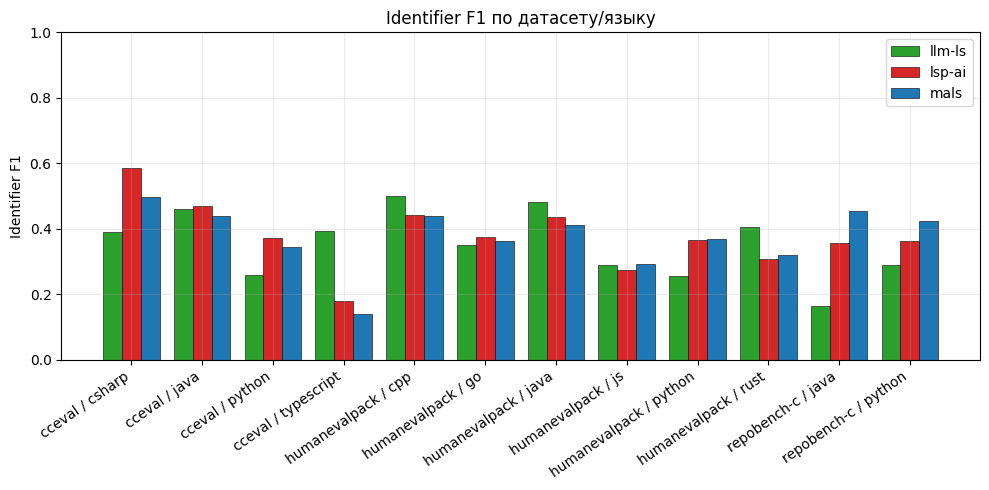

llm-ls edit_similarity [0.4193553470262888, 0.4481965675758993, 0.3648869078672282, 0.370301939734127, 0.3720220589099172, 0.4075492517066163, 0.5332010768003763, 0.3062562858992536, 0.2385626032246325, 0.3346379647749511, 0.10653123867943796, 0.23935553258521808]
lsp-ai edit_similarity [0.48157317869268784, 0.4246377608599511, 0.362890509878837, 0.3813583408689069, 0.38946454391510676, 0.45334376567153123, 0.3982177550525255, 0.33245573830820707, 0.39123159021774834, 0.3231811236737149, 0.3457989613600888, 0.3881293259504218]
mals edit_similarity [0.41247684427305825, 0.38329738783503703, 0.31595351248189446, 0.37294351131432085, 0.3867305680635623, 0.44982823855768395, 0.4090222576698144, 0.29872850293349923, 0.28038284605272956, 0.320239268437717, 0.43399008311468373, 0.42191435370696834]


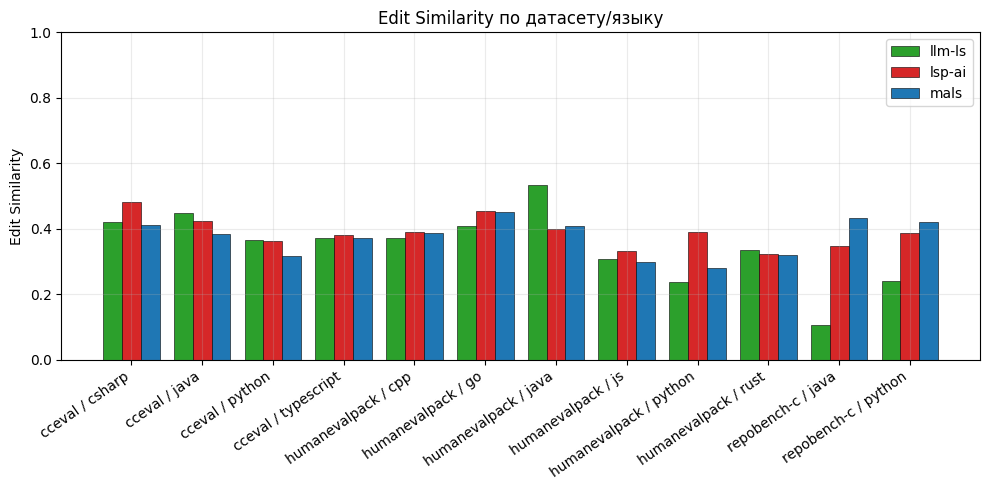

llm-ls hallucination_rate [0.4133333333333334, 0.435, 0.05, 0.2117647058823529, 0.25, 0.04, 0.02, 0.05, 0.2355555555555556, 0.01, 0.48, 0.0]
lsp-ai hallucination_rate [0.425, 0.4, 0.25, 0.425, 0.475, 0.02, 0.5, 0.2, 0.05, 0.0, 0.4447368421052632, 0.07]
mals hallucination_rate [0.5, 0.45, 0.325, 0.45, 0.5, 0.0, 0.45, 0.5, 0.05, 0.02, 0.48, 0.025]


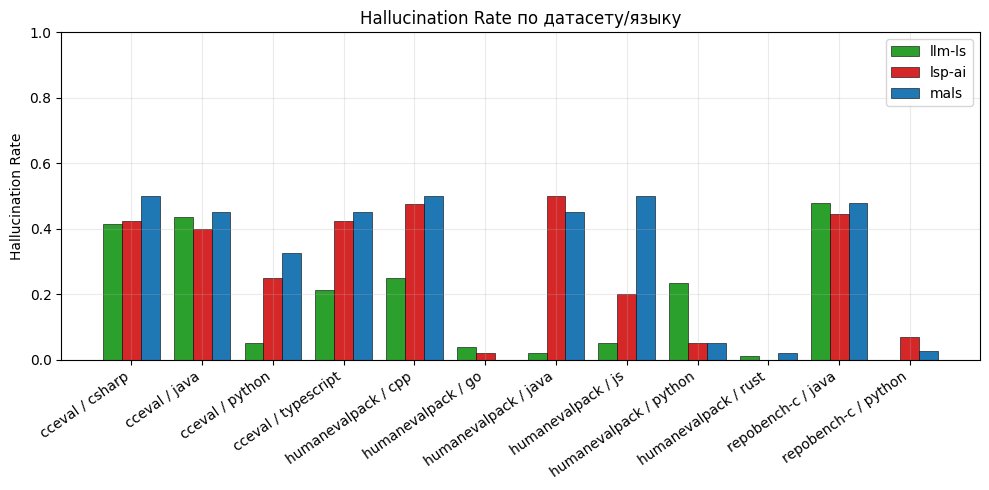

In [422]:
language_rows = add_label(metric_rows, 'dataset', 'language')
plot_grouped_bars(language_rows, 'identifier_f1', text('by_dataset_language_identifier_f1'))
plot_grouped_bars(language_rows, 'edit_similarity', text('by_dataset_language_edit_similarity'))
plot_grouped_bars(language_rows, 'hallucination_rate', text('by_dataset_language_hallucination_rate'))


## Aggregated Across Languages


llm-ls identifier_f1 [0.39043459084854576, 0.3791052097230102, 0.20738384456725284]
lsp-ai identifier_f1 [0.4010411552204694, 0.3669862089526356, 0.35990592421626905]
mals identifier_f1 [0.35453031569879395, 0.365919202217203, 0.43952950723112016]


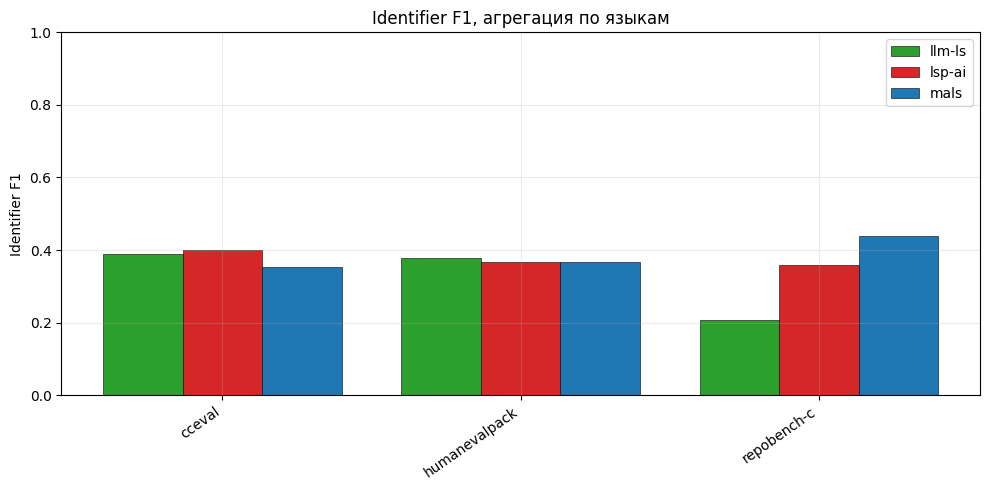

llm-ls edit_similarity [0.4033800813299087, 0.3752250073952897, 0.15396848650293088]
lsp-ai edit_similarity [0.41261494757509576, 0.3813157528064723, 0.36750684063718264]
mals edit_similarity [0.3711678139760776, 0.3574886136191677, 0.4279522184108261]


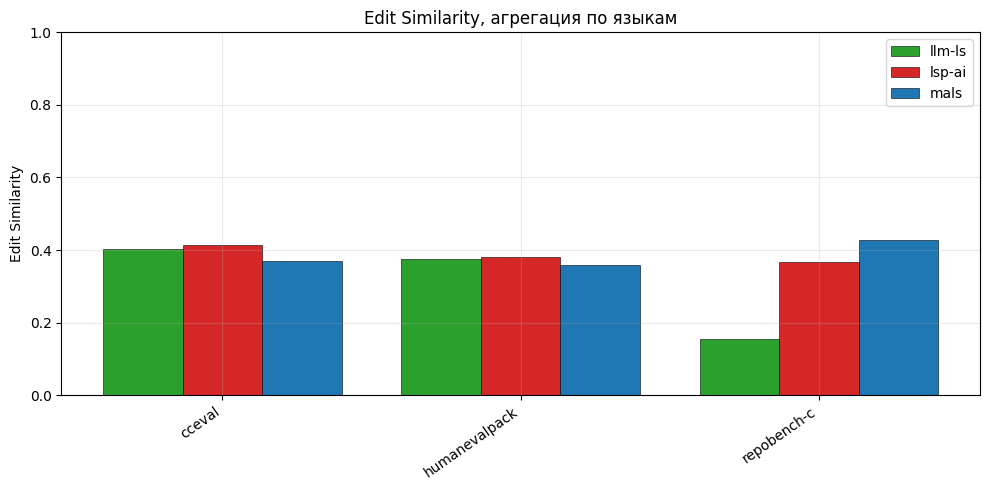

llm-ls hallucination_rate [0.29574074074074075, 0.11701030927835053, 0.3085714285714286]
lsp-ai hallucination_rate [0.375, 0.2075, 0.2525641025641026]
mals hallucination_rate [0.43125, 0.2533333333333333, 0.2525]


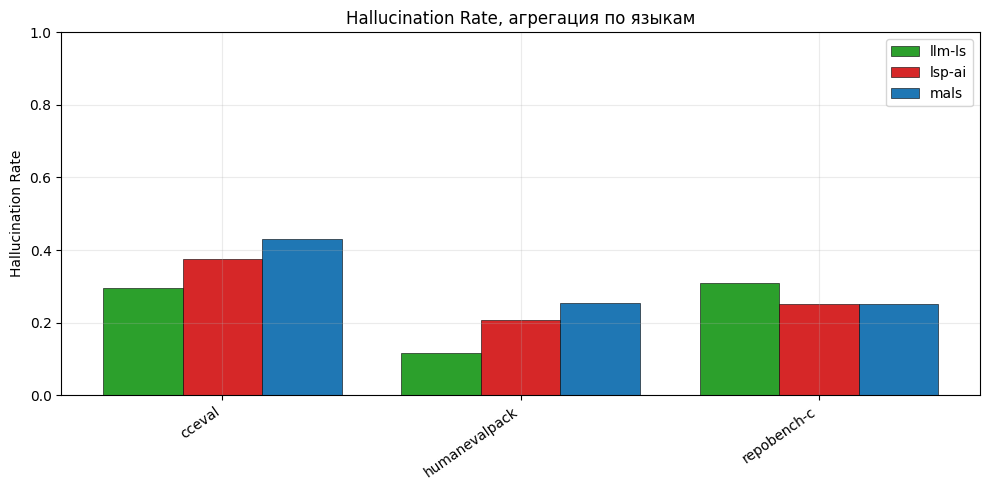

[MetricRow(dataset='cceval', language='', server='llm-ls', count=54, identifier_f1=0.39043459084854576, edit_similarity=0.4033800813299087, exact_match=None, hallucination_rate=0.29574074074074075, new_diagnostic_count=None, completion_diagnostic_count=None, label='cceval'),
 MetricRow(dataset='cceval', language='', server='lsp-ai', count=80, identifier_f1=0.4010411552204694, edit_similarity=0.41261494757509576, exact_match=None, hallucination_rate=0.375, new_diagnostic_count=None, completion_diagnostic_count=None, label='cceval'),
 MetricRow(dataset='cceval', language='', server='mals', count=80, identifier_f1=0.35453031569879395, edit_similarity=0.3711678139760776, exact_match=None, hallucination_rate=0.43125, new_diagnostic_count=None, completion_diagnostic_count=None, label='cceval'),
 MetricRow(dataset='humanevalpack', language='', server='llm-ls', count=97, identifier_f1=0.3791052097230102, edit_similarity=0.3752250073952897, exact_match=None, hallucination_rate=0.117010309278350

In [423]:
dataset_rows = aggregate(metric_rows, ['dataset', 'server'], ['identifier_f1', 'edit_similarity', 'hallucination_rate'])
dataset_rows = add_label(dataset_rows, 'dataset')
plot_grouped_bars(dataset_rows, 'identifier_f1', text('by_dataset_identifier_f1'))
plot_grouped_bars(dataset_rows, 'edit_similarity', text('by_dataset_edit_similarity'))
plot_grouped_bars(dataset_rows, 'hallucination_rate', text('by_dataset_hallucination_rate'))
dataset_rows


## Overall Server Comparison


identifier_f1 ('llm-ls', 0.35566156925607006) ('lsp-ai', 0.3772299938761018) ('mals', 0.3743912908800528)


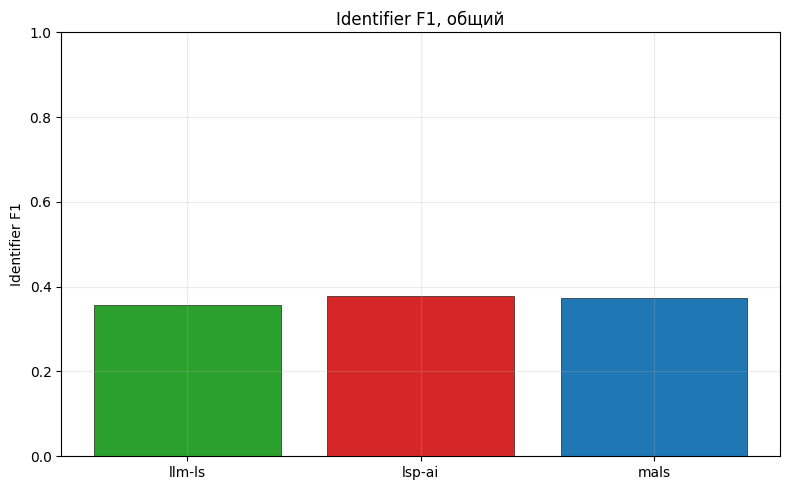

edit_similarity ('llm-ls', 0.3491087582750851) ('lsp-ai', 0.3895391335884287) ('mals', 0.3737922812034141)


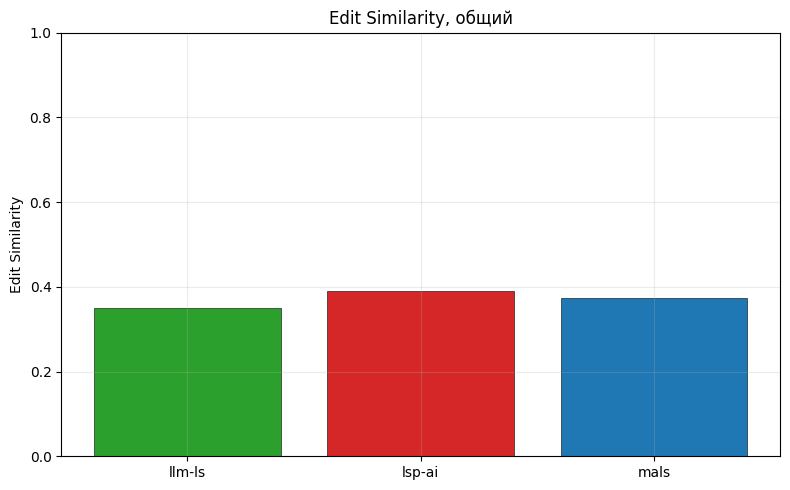

hallucination_rate ('llm-ls', 0.20089385474860336) ('lsp-ai', 0.2709205020920502) ('mals', 0.3125)


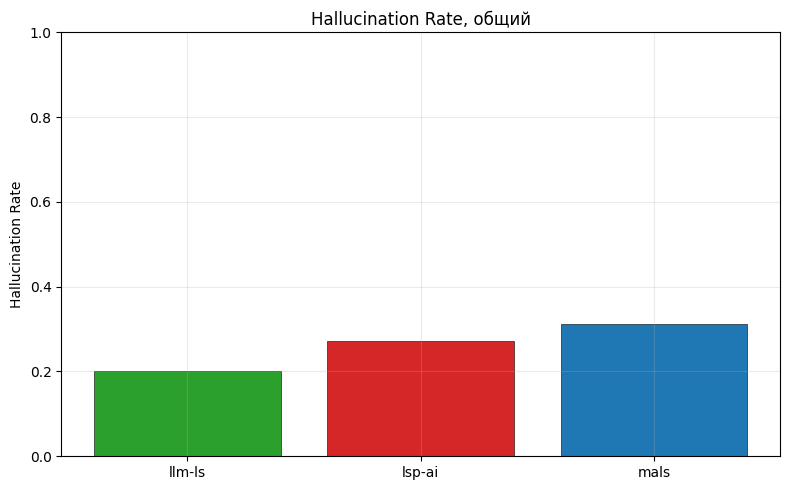

[MetricRow(dataset='', language='', server='llm-ls', count=179, identifier_f1=0.35566156925607006, edit_similarity=0.3491087582750851, exact_match=None, hallucination_rate=0.20089385474860336, new_diagnostic_count=None, completion_diagnostic_count=None, label=''),
 MetricRow(dataset='', language='', server='lsp-ai', count=239, identifier_f1=0.3772299938761018, edit_similarity=0.3895391335884287, exact_match=None, hallucination_rate=0.2709205020920502, new_diagnostic_count=None, completion_diagnostic_count=None, label=''),
 MetricRow(dataset='', language='', server='mals', count=240, identifier_f1=0.3743912908800528, edit_similarity=0.3737922812034141, exact_match=None, hallucination_rate=0.3125, new_diagnostic_count=None, completion_diagnostic_count=None, label='')]

In [424]:
overall_rows = aggregate(metric_rows, ['server'], ['identifier_f1', 'edit_similarity', 'hallucination_rate'])
plot_server_bars(overall_rows, 'identifier_f1', text('overall_identifier_f1'))
plot_server_bars(overall_rows, 'edit_similarity', text('overall_edit_similarity'))
plot_server_bars(overall_rows, 'hallucination_rate', text('overall_hallucination_rate'))
overall_rows
